In [1]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/MHSXtraPy/")

from mhsxtrapy.b3d import WhichSolution
from mhsxtrapy.examples import multipole
from mhsxtrapy.field2d import Field2dData, FluxBalanceState, check_fluxbalance
from mhsxtrapy.field3d import calculate_magfield
from mhsxtrapy.plotting.vis import (
    plot_ddensity_xy,
    plot_ddensity_z,
    plot_dpressure_xy,
    plot_dpressure_z,
    plot_magnetogram_2D,
    plot_magnetogram_3D,
)

import numpy as np
import matplotlib.pyplot as plt
import sunpy
import sunpy.visualization
from astropy.visualization import ImageNormalize
from streamtracer import StreamTracer, VectorGrid

In [4]:
nx, ny, nz, nf = 960, 540, 540, 540
# xmin, xmax, ymin, ymax, zmin, zmax = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0

pixelsize_x = 0.23712652199468398
pixelsize_y = pixelsize_x
pixelsize_z = pixelsize_x

# x_arr = np.linspace(xmin, xmax, nx, dtype=np.float64)
# y_arr = np.linspace(ymin, ymax, ny, dtype=np.float64)
# z_arr = np.linspace(zmin, zmax, nz, dtype=np.float64)
x_arr = np.arange(nx) * pixelsize_x
y_arr = np.arange(ny) * pixelsize_y
z_arr = np.arange(nz) * pixelsize_z

In [5]:
x_arr[0], x_arr[-1]

(0.0, 227.40433459290193)

In [6]:
data_bz = np.load("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.npy").T

In [7]:
data2d = Field2dData(
    nx,
    ny,
    nz,
    nf,
    pixelsize_x,
    pixelsize_y,
    pixelsize_z,
    x_arr,
    y_arr,
    z_arr,
    data_bz,
    flux_balance_state=FluxBalanceState.UNBALANCED,
)

In [8]:
data3d = calculate_magfield(
    data2d,
    alpha=0.004884580737794221,
    a=0.2,
    which_solution=WhichSolution.ASYMP,
    b=1.0,
    z0=2.0,
    deltaz=0.2,
)

In [17]:
data3d.save(path="../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full/")

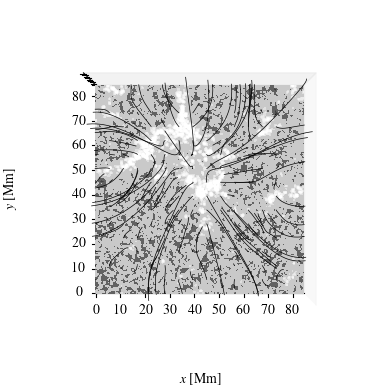

In [18]:
# %matplotlib ipympl 
%matplotlib inline

plot_magnetogram_3D(data3d, view="los", footpoints="all")

In [19]:
bx_extra = data3d.field[:,:,:,1]
by_extra = data3d.field[:,:,:,0]
bz_extra = data3d.field[:,:,:,2]

bx_extra = bx_extra[ny:ny*2, nx:nx*2,:]
by_extra = by_extra[ny:ny*2, nx:nx*2,:]
bz_extra = bz_extra[ny:ny*2, nx:nx*2,:]

In [20]:
np.isnan(bz_extra).all()

False

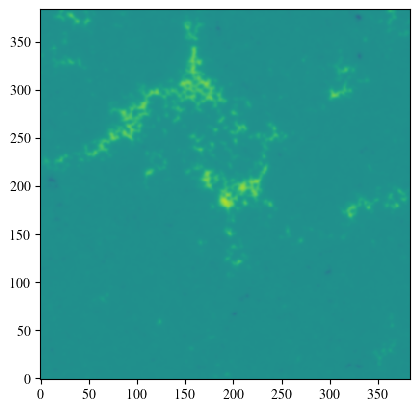

In [21]:
fig, ax = plt.subplots()
ax.imshow(bz_extra[:, :, 1], origin="lower", interpolation="none",
          norm=ImageNormalize(
               vmin=-1500,
               vmax=1500),
          )

In [22]:
field_array = np.array([bx_extra.transpose(1,0,2), by_extra.transpose(1,0,2), bz_extra.transpose(1,0,2)]).transpose(1,2,3,0)

In [23]:
field_grid = VectorGrid(field_array, grid_coords=[x_arr, y_arr, z_arr])

In [24]:
seeds = np.array([[ii, jj, 0] for ii in np.linspace(x_arr[0], x_arr[-1], 32) for jj in np.linspace(y_arr[0], y_arr[-1], 32)])

In [25]:
nsteps = 10000
step_size = 0.1
tracer = StreamTracer(nsteps, step_size)
tracer.trace(seeds, field_grid)

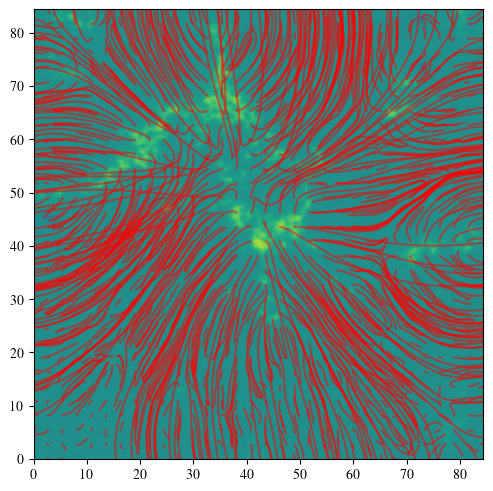

In [26]:
fig, ax = plt.subplots(layout="constrained")
ax.imshow(bz_extra[:, :, 1], origin="lower", interpolation="none",
          norm=ImageNormalize(
               vmin=-1500,
               vmax=1500),
          extent=[x_arr[0], x_arr[-1], y_arr[0], y_arr[-1]])

for fline in tracer.xs[:]:
    ax.plot(fline[:,0], fline[:,1], color="red", alpha=0.5)